### Suggested Ensemble Method: Averaging Regressor

### Imports

In [1]:
# !pip install scikit-learn
# !pip install pycaret

In [2]:
# Data handling & visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Preprocessing & transformations
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Ensemble models
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, VotingClassifier

# Gradient boosting libraries
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimization & utilities
from scipy.stats import randint, uniform
from tqdm.auto import tqdm
import joblib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

results_dir = "../results/"


### Load the dataset

In [3]:
data = pd.read_csv("../datasets/student-mat.csv")      # treat '?' as NaN
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
use_features = [
    "studytime",
    "failures",
    "absences",
    "Medu",
    "Fedu",
    "schoolsup",
    "famsup",
    "higher",
    "internet",
    "activities",
    "traveltime",
    "famrel",
    "goout",
    "health",
    "G1",
    "G2",
    "G3"
]

data = data[use_features]

In [7]:
# data.drop(columns=["school", "sex", "address", "famsize", "Pstatus", "guardian", "romantic", "health", "freetime"], inplace=True)

In [8]:
# Renaming columns to remove spaces and special characters for easier access
data.columns = data.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,G3
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,5,6,6
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,5,5,6
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,7,8,10
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,15,14,15
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,6,10,10


In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
absences,395.0,5.708861,8.003096,0.0,0.0,4.0,8.0,75.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
health,395.0,3.554430,1.390303,1.0,3.0,4.0,5.0,5.0
G1,395.0,10.908861,3.319195,3.0,8.0,11.0,13.0,19.0


In [10]:
data["G3"] = data["G3"]*5
data["G2"] = data["G2"]*5
data["G1"] = data["G1"]*5

data.rename(columns={"G3": "final_score"}, inplace=True)
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,30
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,30
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,50
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,75
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,50


In [11]:
# data["final_grade"] = data["final_score"].apply(lambda x: "PASS" if x >= 40 else "FAIL")
# data.head()

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
dtypes: int64(12), object(5)
memory usage: 52.6+ KB


In [13]:
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,30
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,30
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,50
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,75
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,50


In [14]:
categorical_cols = data.select_dtypes(include="object")
categorical_cols.describe()

,schoolsup,famsup,higher,internet,activities
count,395,395,395,395,395
unique,2,2,2,2,2
top,no,yes,yes,yes,yes
freq,344,242,375,329,201


In [15]:
categorical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   schoolsup   395 non-null    object
 1   famsup      395 non-null    object
 2   higher      395 non-null    object
 3   internet    395 non-null    object
 4   activities  395 non-null    object
dtypes: object(5)
memory usage: 15.6+ KB


In [16]:
categorical_cols.head()

,schoolsup,famsup,higher,internet,activities
0,yes,no,yes,no,no
1,no,yes,yes,yes,no
2,yes,no,yes,yes,no
3,no,yes,yes,yes,yes
4,no,yes,yes,no,no


In [17]:
numerical_cols = data.select_dtypes(include=np.number)
numerical_cols.describe().T

,count,mean,std,min,25%,50%,75%,max
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
absences,395.0,5.708861,8.003096,0.0,0.0,4.0,8.0,75.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
health,395.0,3.554430,1.390303,1.0,3.0,4.0,5.0,5.0
G1,395.0,54.544304,16.595973,15.0,40.0,55.0,65.0,95.0


In [18]:
numerical_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   studytime    395 non-null    int64
 1   failures     395 non-null    int64
 2   absences     395 non-null    int64
 3   Medu         395 non-null    int64
 4   Fedu         395 non-null    int64
 5   traveltime   395 non-null    int64
 6   famrel       395 non-null    int64
 7   goout        395 non-null    int64
 8   health       395 non-null    int64
 9   G1           395 non-null    int64
 10  G2           395 non-null    int64
 11  final_score  395 non-null    int64
dtypes: int64(12)
memory usage: 37.2 KB


In [19]:
numerical_cols.head()

,studytime,failures,absences,Medu,Fedu,traveltime,famrel,goout,health,G1,G2,final_score
0,2,0,6,4,4,2,4,4,3,25,30,30
1,2,0,4,1,1,1,5,3,3,25,25,30
2,2,3,10,1,1,1,4,2,3,35,40,50
3,3,0,2,4,2,1,3,2,5,75,70,75
4,2,0,4,3,3,1,4,2,5,30,50,50


### Exploratory Data Analysis

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
dtypes: int64(12), object(5)
memory usage: 52.6+ KB


In [21]:
data.describe(exclude=np.number).T

,count,unique,top,freq
schoolsup,395,2,no,344
famsup,395,2,yes,242
higher,395,2,yes,375
internet,395,2,yes,329
activities,395,2,yes,201


In [22]:
for col in categorical_cols.columns:
    print(f"Value counts for {col}:")
    print(categorical_cols[col].value_counts())
    print("\n")

Value counts for schoolsup:
schoolsup
no     344
yes     51
Name: count, dtype: int64


Value counts for famsup:
famsup
yes    242
no     153
Name: count, dtype: int64


Value counts for higher:
higher
yes    375
no      20
Name: count, dtype: int64


Value counts for internet:
internet
yes    329
no      66
Name: count, dtype: int64


Value counts for activities:
activities
yes    201
no     194
Name: count, dtype: int64




In [23]:
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,30
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,30
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,50
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,75
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,50


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
dtypes: int64(12), object(5)
memory usage: 52.6+ KB


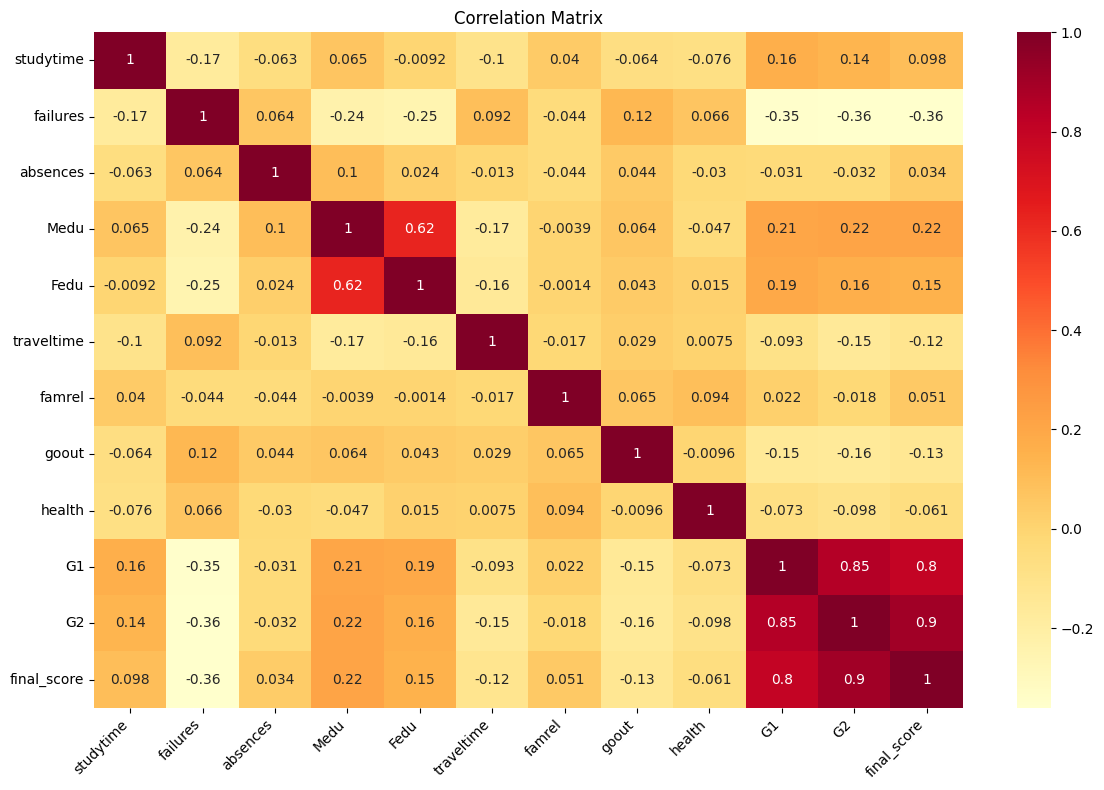

In [25]:
# Correlation Analysis
columns = data.select_dtypes(include=np.number).columns
correlation_matrix = data[columns].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlOrRd")
plt.xticks(rotation=45, ha="right")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(results_dir + "correlation_analysis.png", dpi=400)
plt.show()

In [26]:

# # fig, ax = plt.subplots()
# # ax.pie(sizes, labels=labels)
# # fig, ax = plt.subplots()

# plt.pie(data["final_grade"].value_counts().values, labels=data["final_grade"].final_grade.value_counts().index, autopct='%.0f%%',
#        textprops={'size': 'smaller'}, radius=0.5)
# plt.show()

In [27]:
# grade_count = data.final_grade.value_counts().values
# grade_labels = data.final_grade.value_counts().index
# grade_labels

In [28]:
# # Create pie chart
# plt.figure(figsize=(6, 5))
# plt.pie(
#     grade_count,
#     labels=grade_labels,
#     autopct='%1.1f%%',
#     startangle=90,
# )
# plt.title("Distribution of Classes")
# plt.tight_layout()
# plt.savefig(results_dir + "class_distribution_pie.png", dpi=400)
# plt.show()

### Bar Plots

In [29]:
# for col in numerical_cols:
    
#     total_values = data.groupby("final_grade")[col].sum().sort_values(ascending=False)
    
#     plt.figure(figsize=(10, 6))
#     total_values.plot(kind='bar', color='blue', edgecolor='black')
    
#     plt.title(f"Total {col.replace('_',' ').title()} by Final Grade", fontsize=14)
#     plt.xlabel("Final Grade", fontsize=12)
#     plt.ylabel(f"Total {col.replace('_',' ').title()}", fontsize=12)
    
#     plt.xticks(rotation=45)
#     plt.grid(axis='y', linestyle='--', alpha=0.7)
#     plt.tight_layout()
    
#     plt.savefig(results_dir + f"total_{col}_by_final_grade.png", dpi=400)
#     plt.show()


In [30]:
numerical_cols = data.describe().columns
numerical_cols

Index(['studytime', 'failures', 'absences', 'Medu', 'Fedu', 'traveltime',
       'famrel', 'goout', 'health', 'G1', 'G2', 'final_score'],
      dtype='object')

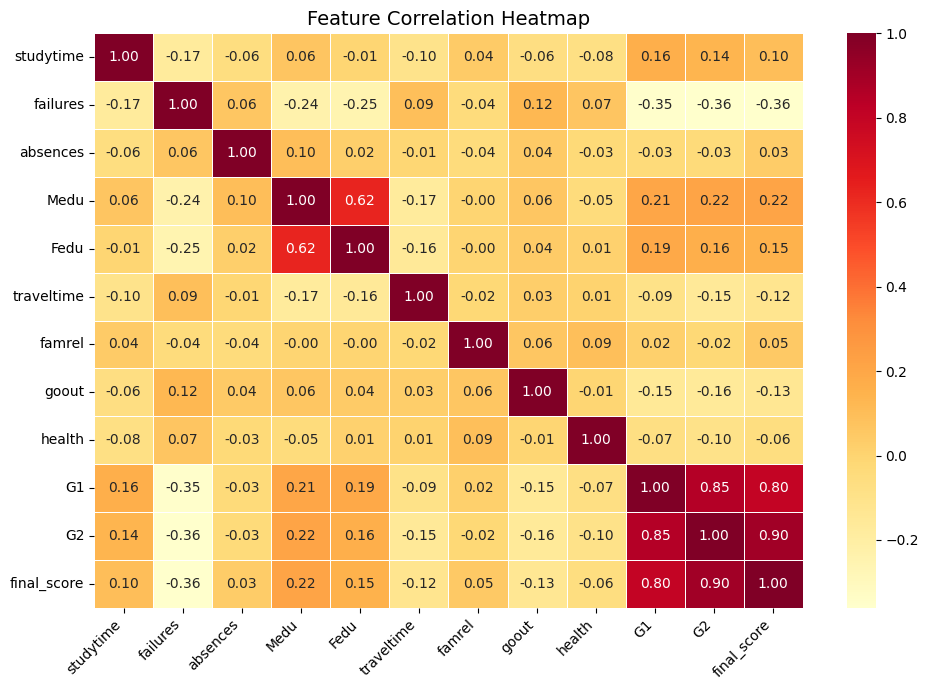

In [31]:
# Heatmap – Correlation Matrix
plt.figure(figsize=(10, 7))
corr = data[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(results_dir + "07_correlation_heatmap.png", dpi=400)
plt.show()

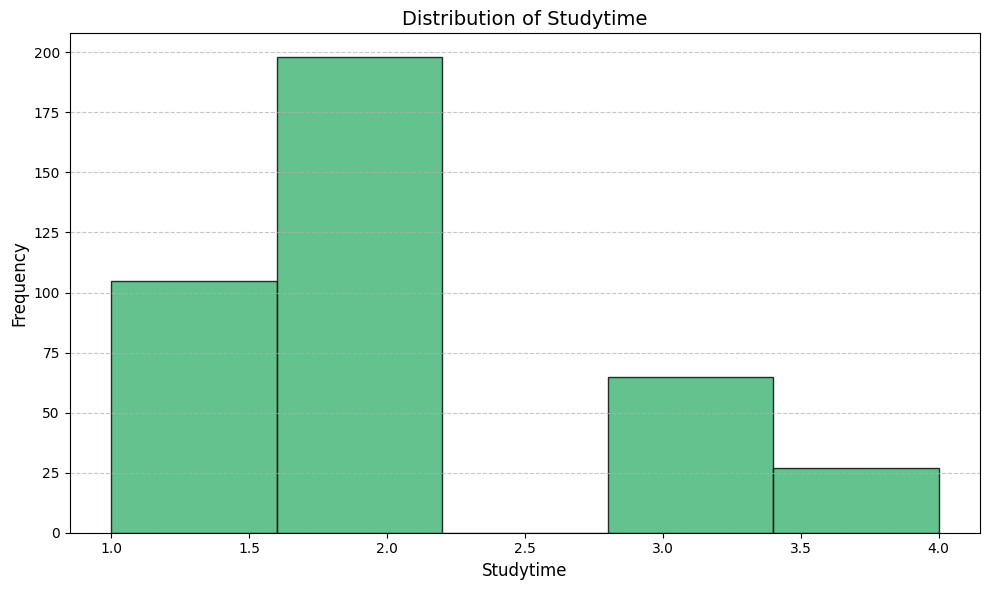

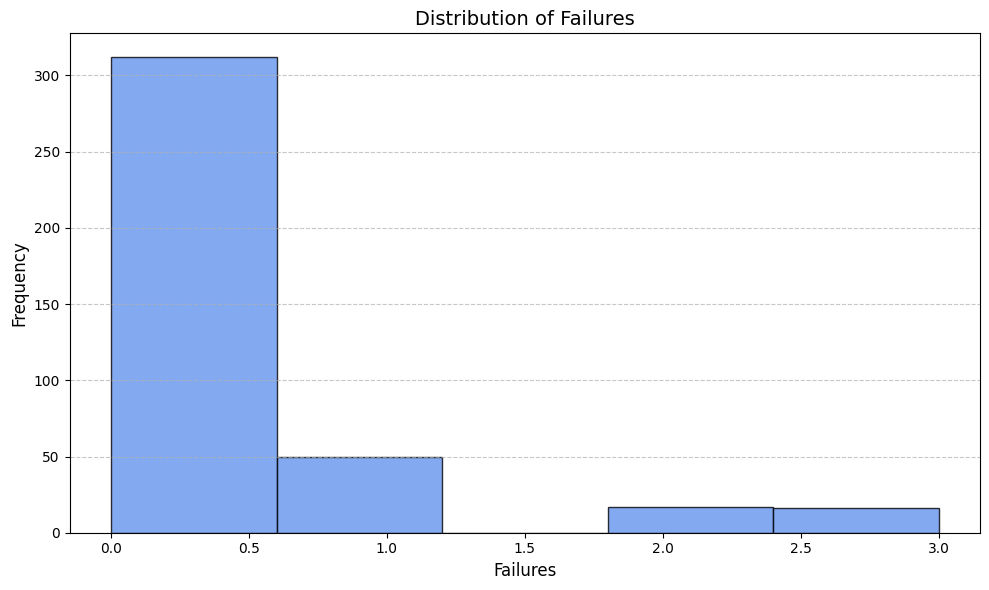

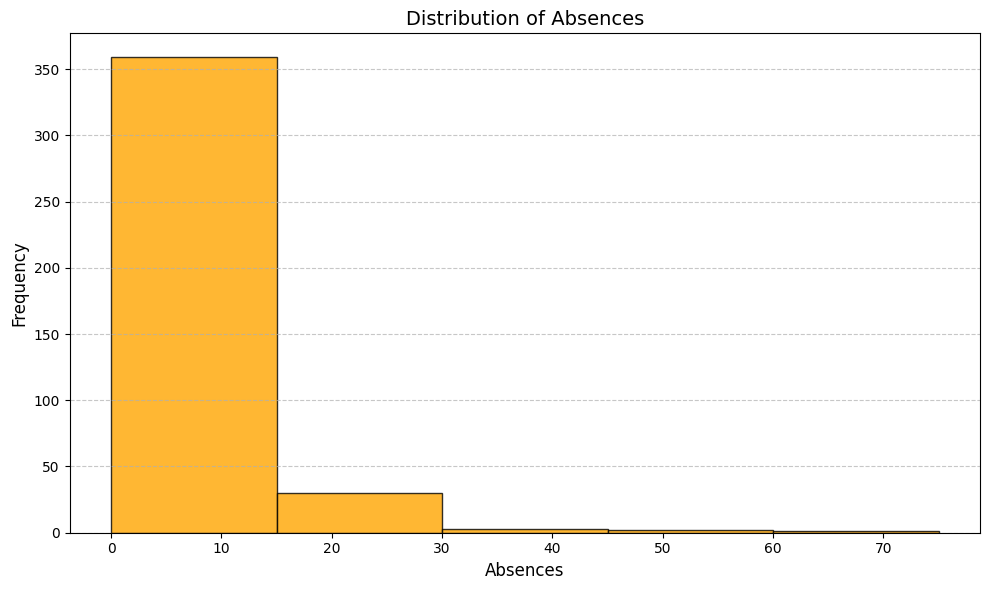

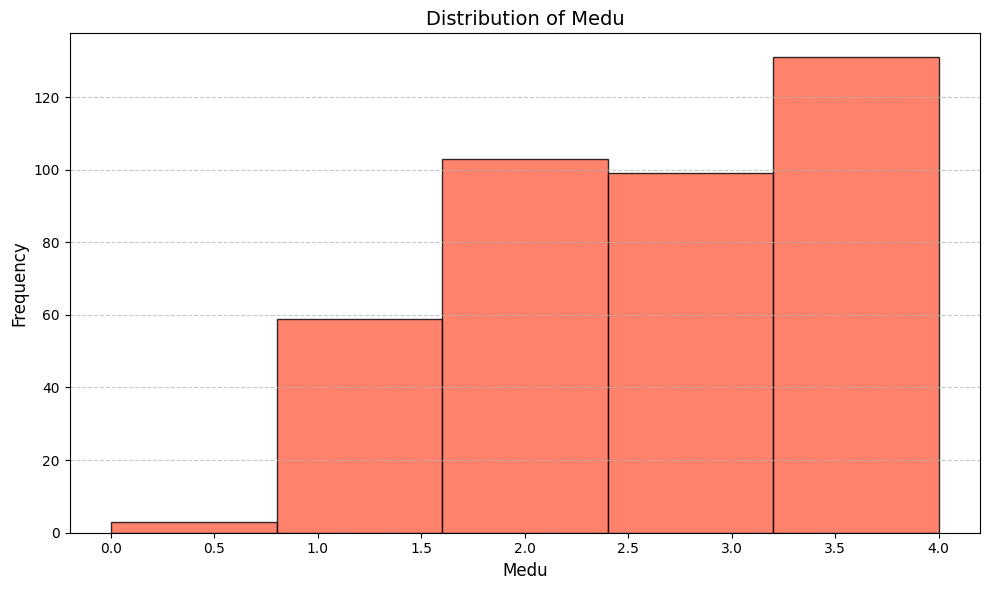

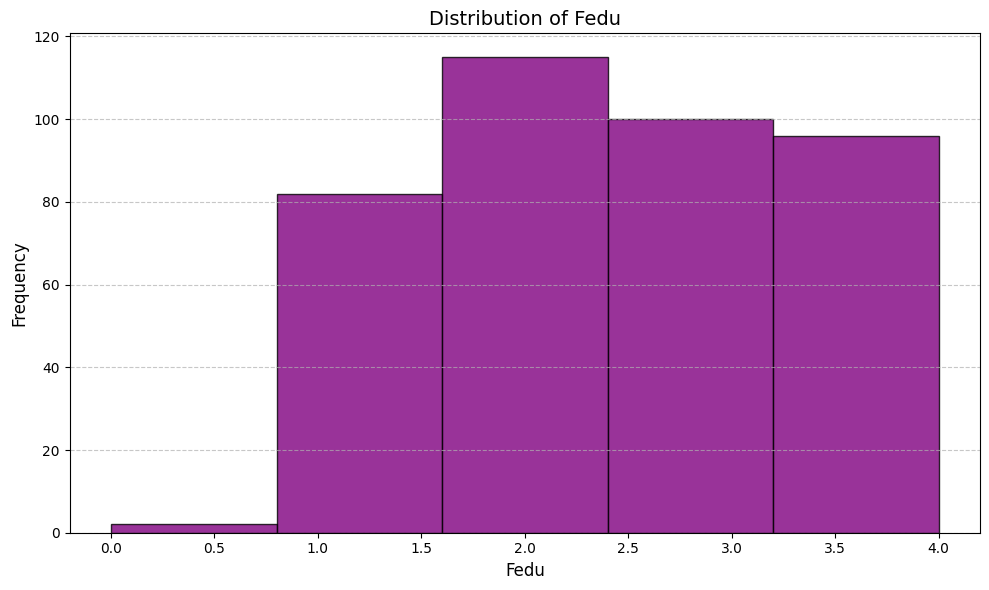

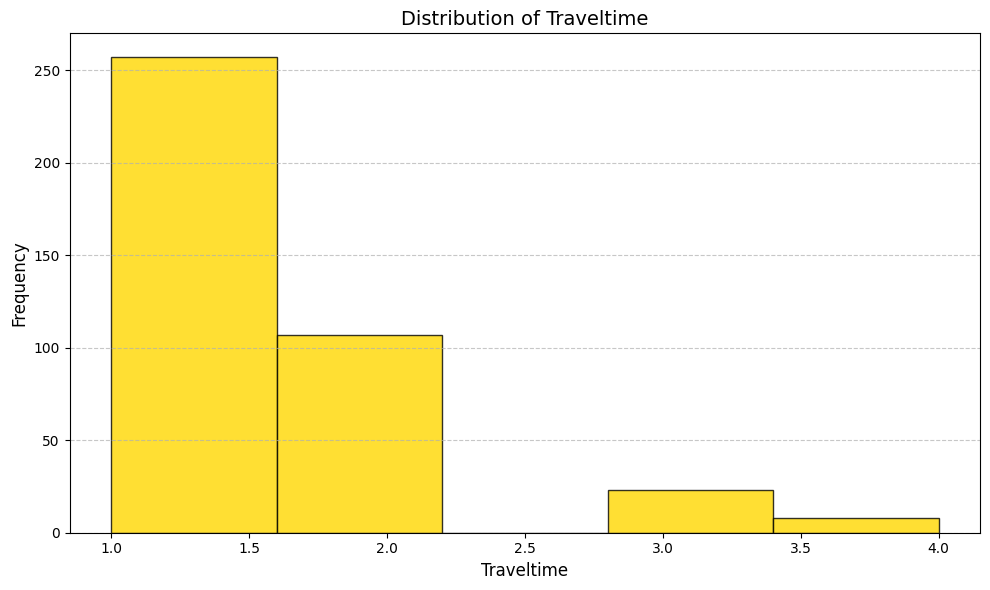

In [32]:
# Histogram Plots

# Different colors for each histogram
colors = [
    "mediumseagreen",
    "cornflowerblue",
    "orange",
    "tomato",
    "purple",
    "gold"
]

for col, color in zip(numerical_cols, colors):

    plt.figure(figsize=(10, 6))
    plt.hist(data[col], bins=5, color=color, edgecolor='black', alpha=0.8)

    plt.title(f"Distribution of {col.replace('_',' ').title()}", fontsize=14)
    plt.xlabel(col.replace('_',' ').title(), fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(results_dir + f"hist_{col}.png", dpi=400)
    plt.show()


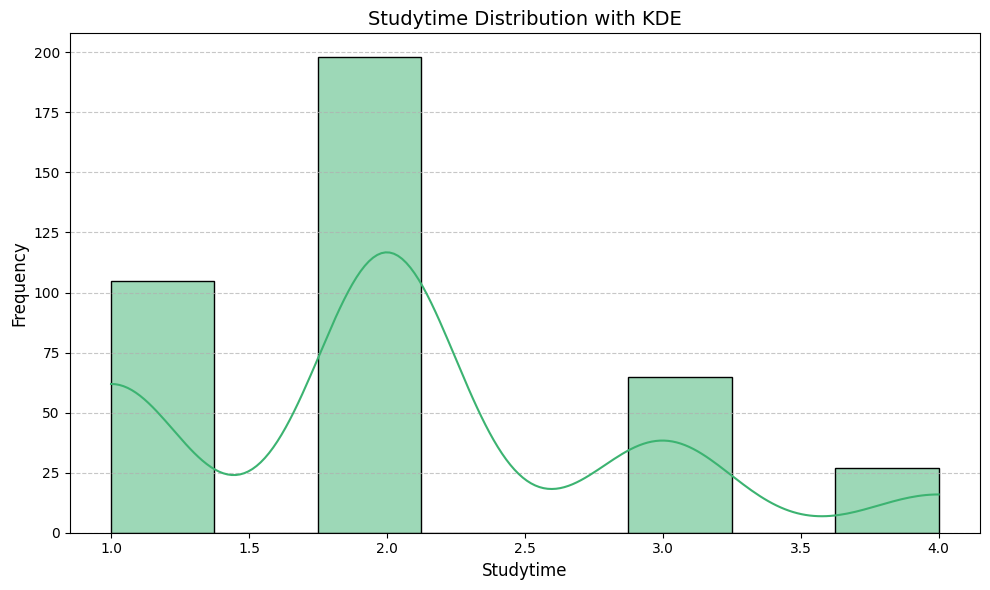

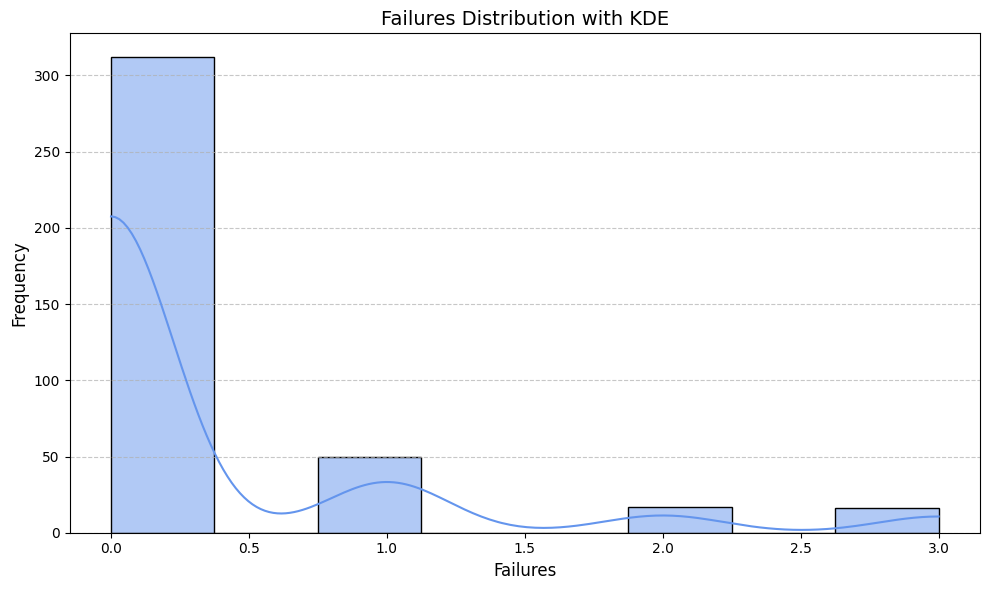

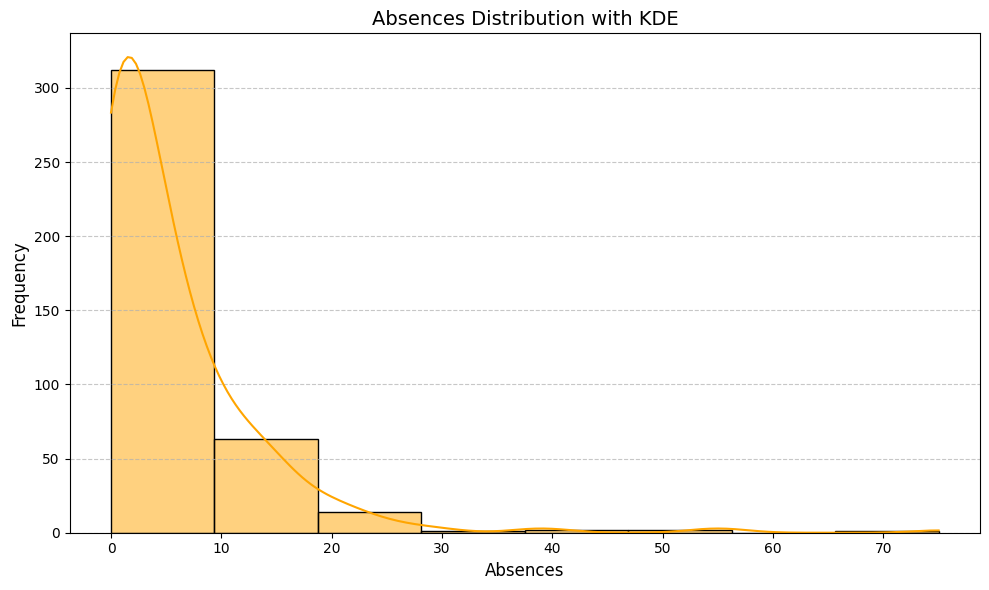

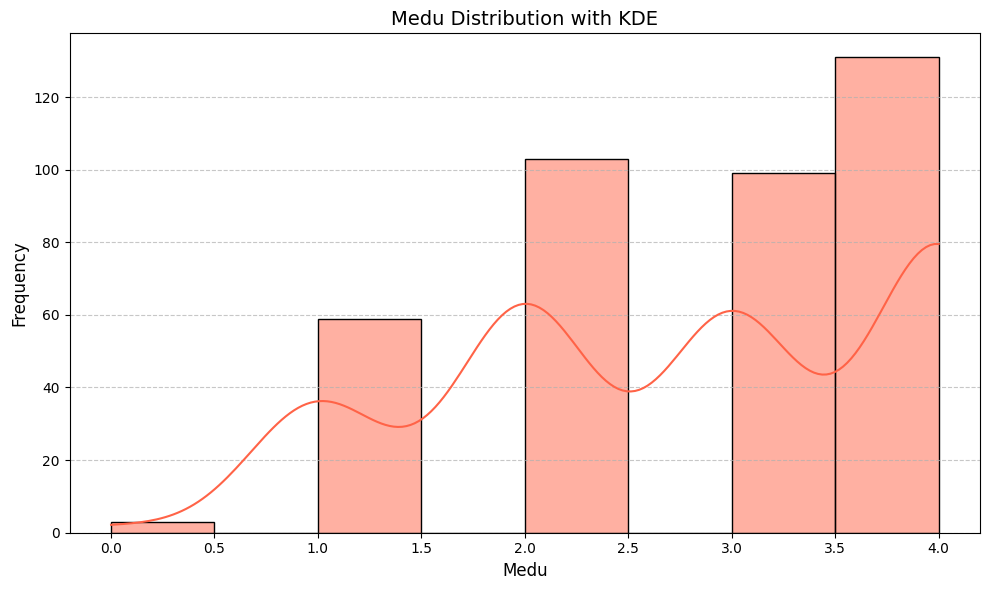

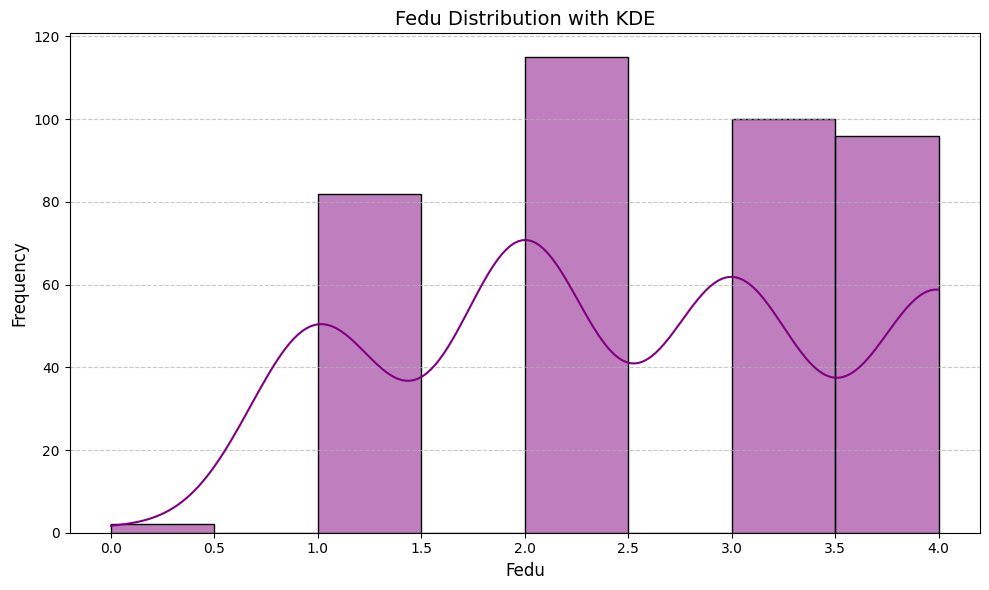

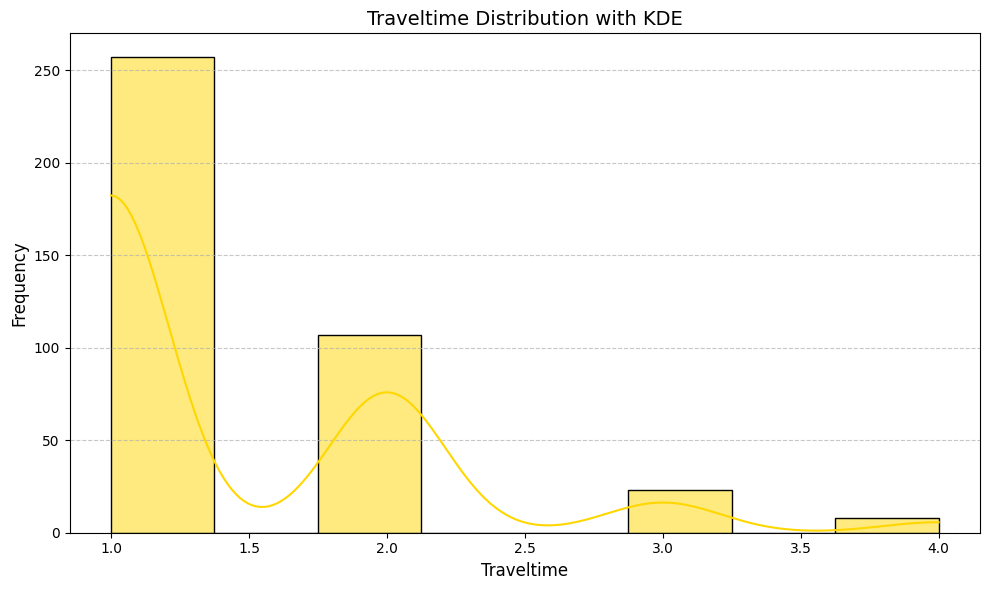

In [33]:
# Histogram Distribution with KDE
for col, color in zip(numerical_cols, colors):

    plt.figure(figsize=(10, 6))
    
    sns.histplot(
        data[col].dropna(),
        kde=True,
        bins=8,
        color=color
    )

    plt.title(f"{col.replace('_',' ').title()} Distribution with KDE", fontsize=14)
    plt.xlabel(col.replace('_',' ').title(), fontsize=12)
    plt.ylabel("Frequency", fontsize=12)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(results_dir + f"kde_{col}.png", dpi=400)
    plt.show()


In [34]:
for col in data.columns:
    print(f"\nColumn name: {col}")
    print(f"Unique values in each column: {data[col].unique()}")


Column name: studytime
Unique values in each column: [2 3 1 4]

Column name: failures
Unique values in each column: [0 3 2 1]

Column name: absences
Unique values in each column: [ 6  4 10  2  0 16 14  7  8 25 12 54 18 26 20 56 24 28  5 13 15 22  3 21
  1 75 30 19  9 11 38 40 23 17]

Column name: Medu
Unique values in each column: [4 1 3 2 0]

Column name: Fedu
Unique values in each column: [4 1 2 3 0]

Column name: schoolsup
Unique values in each column: ['yes' 'no']

Column name: famsup
Unique values in each column: ['no' 'yes']

Column name: higher
Unique values in each column: ['yes' 'no']

Column name: internet
Unique values in each column: ['no' 'yes']

Column name: activities
Unique values in each column: ['no' 'yes']

Column name: traveltime
Unique values in each column: [2 1 3 4]

Column name: famrel
Unique values in each column: [4 5 3 1 2]

Column name: goout
Unique values in each column: [4 3 2 1 5]

Column name: health
Unique values in each column: [3 5 1 2 4]

Column nam

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
dtypes: int64(12), object(5)
memory usage: 52.6+ KB


In [36]:
data.isnull().sum()

studytime      0
failures       0
absences       0
Medu           0
Fedu           0
schoolsup      0
famsup         0
higher         0
internet       0
activities     0
traveltime     0
famrel         0
goout          0
health         0
G1             0
G2             0
final_score    0
dtype: int64

In [37]:
data = data.dropna(subset=['final_score'])

In [38]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
absences,395.0,5.708861,8.003096,0.0,0.0,4.0,8.0,75.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
health,395.0,3.554430,1.390303,1.0,3.0,4.0,5.0,5.0
G1,395.0,54.544304,16.595973,15.0,40.0,55.0,65.0,95.0


In [39]:
# data["attendance_rate"].fillna(data["attendance_rate"].mean(), inplace=True)
# data["study_hours_week"].fillna(data["study_hours_week"].mean(), inplace=True)
# data["prev_grade"].fillna(data["prev_grade"].mean(), inplace=True)
# data["extra_activities"].fillna(data["extra_activities"].mode()[0], inplace=True)
# data["study_hours"].fillna(data["study_hours"].mean(), inplace=True)
# data["attendance_pct"].fillna(data["attendance_pct"].mean(), inplace=True)

In [40]:
# data = data.drop("final_score", axis=1)

### PyCaret Implementation

In [41]:
from pycaret.regression import *

s = setup(data, target = 'final_score', session_id = 123)

,Description,Value
0,Session id,123
1,Target,final_score
2,Target type,Regression
3,Original data shape,"(395, 17)"
4,Transformed data shape,"(395, 17)"
5,Transformed train set shape,"(276, 17)"
6,Transformed test set shape,"(119, 17)"
7,Numeric features,11
8,Categorical features,5
9,Preprocess,True


In [42]:
# compare baseline models
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,5.2864,73.2752,8.4058,0.8386,0.7113,0.0912,0.0520
catboost,CatBoost Regressor,5.5265,77.1146,8.5521,0.8372,0.7848,0.0898,0.1200
xgboost,Extreme Gradient Boosting,5.4029,76.8952,8.5744,0.8334,0.6687,0.0977,0.0620
et,Extra Trees Regressor,5.4404,77.3727,8.6330,0.8325,0.7149,0.0890,0.0440
gbr,Gradient Boosting Regressor,5.5835,79.3968,8.7082,0.8299,0.7041,0.1004,0.0260
lightgbm,Light Gradient Boosting Machine,6.1489,82.8753,8.9477,0.8199,0.7635,0.1117,0.5890
ada,AdaBoost Regressor,6.0527,85.3998,9.1025,0.8100,0.7981,0.1027,0.0270
br,Bayesian Ridge,5.7016,91.4458,9.3213,0.8086,0.8373,0.0820,0.0130
llar,Lasso Least Angle Regression,5.6543,92.2938,9.3523,0.8076,0.8460,0.0804,0.0150
lasso,Lasso Regression,5.6544,92.2936,9.3523,0.8076,0.8460,0.0804,0.1830


In [43]:
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score
0,2,0,6,4,4,yes,no,yes,no,no,2,4,4,3,25,30,30
1,2,0,4,1,1,no,yes,yes,yes,no,1,5,3,3,25,25,30
2,2,3,10,1,1,yes,no,yes,yes,no,1,4,2,3,35,40,50
3,3,0,2,4,2,no,yes,yes,yes,yes,1,3,2,5,75,70,75
4,2,0,4,3,3,no,yes,yes,no,no,1,4,2,5,30,50,50


In [44]:
data.isnull().sum()

studytime      0
failures       0
absences       0
Medu           0
Fedu           0
schoolsup      0
famsup         0
higher         0
internet       0
activities     0
traveltime     0
famrel         0
goout          0
health         0
G1             0
G2             0
final_score    0
dtype: int64

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   studytime    395 non-null    int64 
 1   failures     395 non-null    int64 
 2   absences     395 non-null    int64 
 3   Medu         395 non-null    int64 
 4   Fedu         395 non-null    int64 
 5   schoolsup    395 non-null    object
 6   famsup       395 non-null    object
 7   higher       395 non-null    object
 8   internet     395 non-null    object
 9   activities   395 non-null    object
 10  traveltime   395 non-null    int64 
 11  famrel       395 non-null    int64 
 12  goout        395 non-null    int64 
 13  health       395 non-null    int64 
 14  G1           395 non-null    int64 
 15  G2           395 non-null    int64 
 16  final_score  395 non-null    int64 
dtypes: int64(12), object(5)
memory usage: 52.6+ KB


In [46]:
cat_cols = data.select_dtypes(exclude=[np.number]).columns
cat_cols

Index(['schoolsup', 'famsup', 'higher', 'internet', 'activities'], dtype='object')

In [47]:
from sklearn.preprocessing import LabelEncoder

# Categorical columns to encode
# Initialize a dictionary to store encoders (optional, useful for inverse transform)
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # store encoder for later use if needed

In [48]:
import pickle

# Save the dictionary of label encoders to a pickle file
with open(results_dir + "label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print(f"Label encoders saved to '{results_dir}label_encoders.pkl'")

Label encoders saved to '../results/label_encoders.pkl'


In [49]:
# Separating predictors from target
X = data.drop(["final_score"], axis=1)
y = data["final_score"]

# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20)

In [50]:
# X_train, X_test, y_train, y_test = X, X, y, y

In [51]:
X_train

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2
288,3,0,6,2,1,0,0,1,1,1,1,4,4,2,75,70
6,2,0,0,2,2,0,0,1,1,0,1,4,4,3,60,60
226,2,0,10,3,2,0,0,1,1,1,1,5,4,3,80,75
319,2,0,2,4,4,0,1,1,1,0,1,4,4,5,55,55
216,2,2,22,4,3,0,0,1,1,0,1,3,5,1,30,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,2,0,14,4,3,0,0,1,1,1,1,3,3,3,65,65
98,1,0,6,4,4,0,0,1,1,1,1,5,4,1,55,70
322,3,0,3,2,2,0,1,1,1,1,1,3,2,3,55,55
382,2,0,2,2,3,0,0,1,1,1,2,4,3,3,55,55


In [52]:
X_test

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2
252,1,1,4,2,1,0,0,0,1,0,1,3,5,5,30,45
236,2,0,4,2,2,0,0,1,1,1,1,4,2,4,70,65
275,2,0,6,2,2,1,1,1,1,0,2,4,4,5,60,60
148,1,0,0,4,4,0,1,0,1,0,1,3,2,5,35,30
309,2,1,18,1,1,1,1,1,1,1,1,4,3,3,60,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,2,0,2,4,3,0,1,1,1,1,1,4,5,2,80,80
199,2,0,0,4,4,0,1,1,1,0,1,4,2,3,45,45
320,2,0,23,4,3,0,1,1,1,0,1,5,2,5,65,65
375,3,0,2,1,1,0,0,1,1,0,4,4,2,4,40,40


In [53]:
# Display first 5 rows to check
data.head()

,studytime,failures,absences,Medu,Fedu,schoolsup,famsup,higher,internet,activities,traveltime,famrel,goout,health,G1,G2,final_score
0,2,0,6,4,4,1,0,1,0,0,2,4,4,3,25,30,30
1,2,0,4,1,1,0,1,1,1,0,1,5,3,3,25,25,30
2,2,3,10,1,1,1,0,1,1,0,1,4,2,3,35,40,50
3,3,0,2,4,2,0,1,1,1,1,1,3,2,5,75,70,75
4,2,0,4,3,3,0,1,1,0,0,1,4,2,5,30,50,50


In [54]:
for col in data.columns:
    print(f"\nColumn name: {col}")
    print(f"Unique values in each column: {data[col].unique()}")


Column name: studytime
Unique values in each column: [2 3 1 4]

Column name: failures
Unique values in each column: [0 3 2 1]

Column name: absences
Unique values in each column: [ 6  4 10  2  0 16 14  7  8 25 12 54 18 26 20 56 24 28  5 13 15 22  3 21
  1 75 30 19  9 11 38 40 23 17]

Column name: Medu
Unique values in each column: [4 1 3 2 0]

Column name: Fedu
Unique values in each column: [4 1 2 3 0]

Column name: schoolsup
Unique values in each column: [1 0]

Column name: famsup
Unique values in each column: [0 1]

Column name: higher
Unique values in each column: [1 0]

Column name: internet
Unique values in each column: [0 1]

Column name: activities
Unique values in each column: [0 1]

Column name: traveltime
Unique values in each column: [2 1 3 4]

Column name: famrel
Unique values in each column: [4 5 3 1 2]

Column name: goout
Unique values in each column: [4 3 2 1 5]

Column name: health
Unique values in each column: [3 5 1 2 4]

Column name: G1
Unique values in each column:

In [55]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
# Save the dictionary of scaler to a pickle file
with open(results_dir + "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"Scaler saved to '{results_dir}scaler.pkl'")

Scaler saved to '../results/scaler.pkl'


In [57]:
import pandas as pd

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import numpy as np

# -------------------------------------------------------
# Define best regression models
# -------------------------------------------------------

models = {

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        verbose=0,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

# -------------------------------------------------------
# Train and evaluate models
# -------------------------------------------------------

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2,
        mape
    ])

# -------------------------------------------------------
# Convert to dataframe
# -------------------------------------------------------

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "MAPE"
    ]
)

results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)


              Model       MAE        MSE      RMSE        R2          MAPE
2           XGBoost  4.946060  48.534580  6.966676  0.914316  3.657532e+15
0      RandomForest  4.617405  50.857983  7.131478  0.910215  3.949201e+15
4  GradientBoosting  4.818362  55.733132  7.465463  0.901608  4.416298e+15
1          CatBoost  5.286840  58.809394  7.668728  0.896177  4.876608e+15
3        ExtraTrees  5.454430  75.118101  8.667070  0.867386  7.137350e+15


In [58]:
results_df

,Model,MAE,MSE,RMSE,R2,MAPE
2,XGBoost,4.946060,48.534580,6.966676,0.914316,3.657532e+15
0,RandomForest,4.617405,50.857983,7.131478,0.910215,3.949201e+15
4,GradientBoosting,4.818362,55.733132,7.465463,0.901608,4.416298e+15
1,CatBoost,5.286840,58.809394,7.668728,0.896177,4.876608e+15
3,ExtraTrees,5.454430,75.118101,8.667070,0.867386,7.137350e+15


In [59]:
from sklearn.ensemble import VotingRegressor

# Ensemble model using top performing regressors
ensemble_model = VotingRegressor(

    estimators=[

        ('randomforest', models["RandomForest"]),
        ('catboost', models["CatBoost"]),
        ('xgboost', models["XGBoost"]),
        ('extratrees', models["ExtraTrees"]),
        ('gradientboosting', models["GradientBoosting"])

    ]

)


In [60]:
# Example: train and evaluate
ensemble_model.fit(X_train, y_train)
y_pred = ensemble_model.predict(X_test)

In [61]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Ensemble Results")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


Ensemble Results
MAE: 4.75177682474234
MSE: 51.314972474422675
RMSE: 7.163446968772972
R2: 0.9094078771161417


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)


def evaluate_model(model, X_test, y_test, results_dir, name="model"):

    print("\n" + "="*70)
    print(f"EVALUATION: {name}")
    print("="*70)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}")

    # -------------------------------------------------
    # Predicted vs Actual Plot
    # -------------------------------------------------

    plt.figure(figsize=(6,5))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Predicted vs Actual")
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--')
    plt.tight_layout()
    plt.savefig(results_dir + f"{name}_pred_vs_actual.png", dpi=400)
    plt.show()

    # -------------------------------------------------
    # Residual Plot
    # -------------------------------------------------

    residuals = y_test - y_pred

    plt.figure(figsize=(6,5))
    sns.histplot(residuals, kde=True)
    plt.title("Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(results_dir + f"{name}_residuals.png", dpi=400)
    plt.show()

    # -------------------------------------------------
    # Residual Scatter Plot
    # -------------------------------------------------

    plt.figure(figsize=(6,5))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title("Residuals vs Predictions")
    plt.tight_layout()
    plt.savefig(results_dir + f"{name}_residual_scatter.png", dpi=400)
    plt.show()

    # -------------------------------------------------
    # Save model
    # -------------------------------------------------

    joblib.dump(model, results_dir + f"{name}_model.pkl")
    print(f"\nModel saved to: {results_dir}{name}_model.pkl")



EVALUATION: RandomForest
MAE  : 4.6174
MSE  : 50.8580
RMSE : 7.1315
R2   : 0.9102
MAPE : 3949200812482166.5000


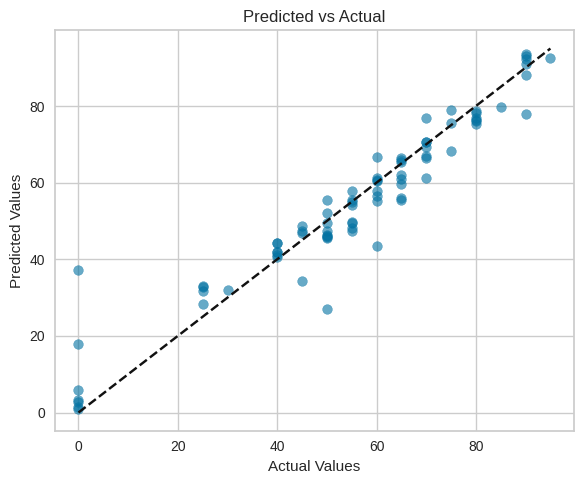

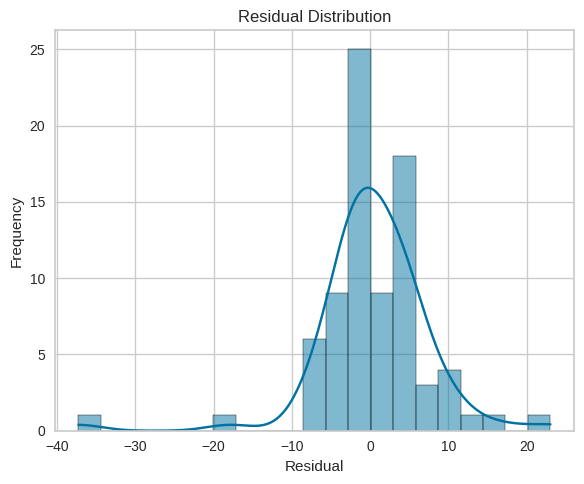

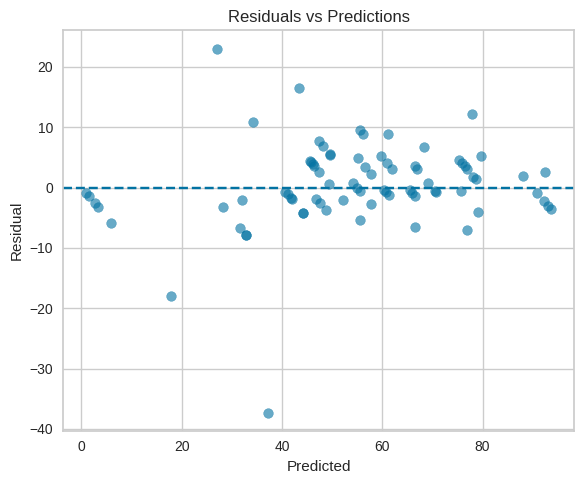


Model saved to: ../results/RandomForest_model.pkl

EVALUATION: CatBoost
MAE  : 5.2868
MSE  : 58.8094
RMSE : 7.6687
R2   : 0.8962
MAPE : 4876607528973594.0000


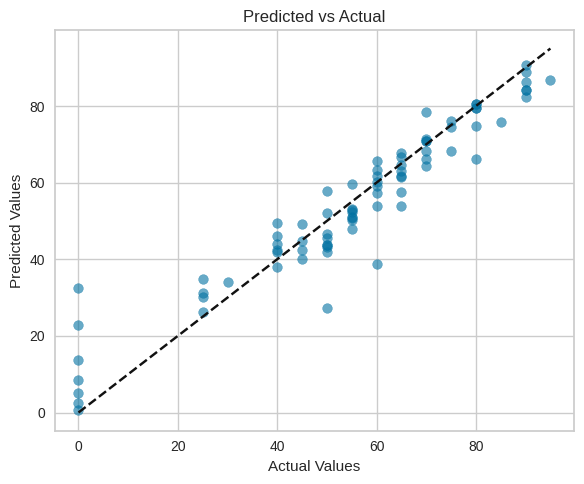

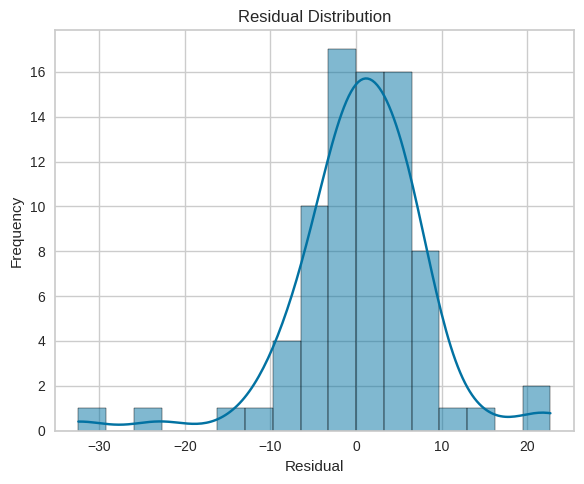

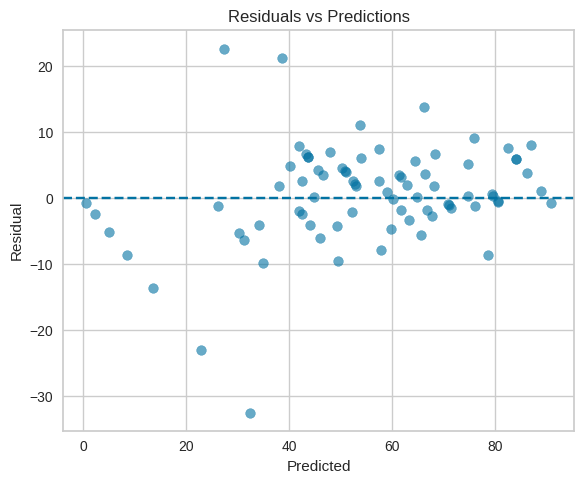


Model saved to: ../results/CatBoost_model.pkl

EVALUATION: XGBoost
MAE  : 4.9461
MSE  : 48.5346
RMSE : 6.9667
R2   : 0.9143
MAPE : 3657532195049938.5000


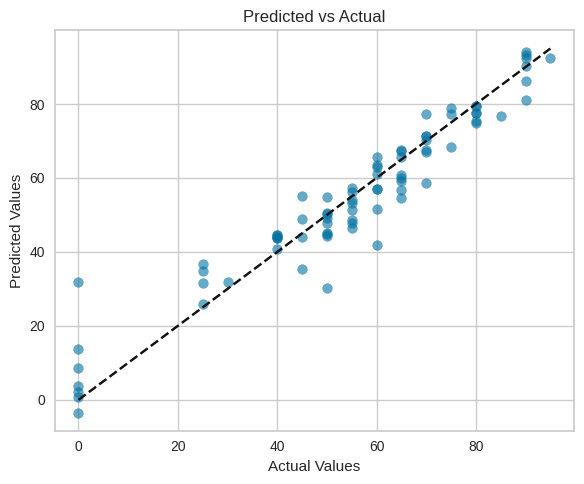

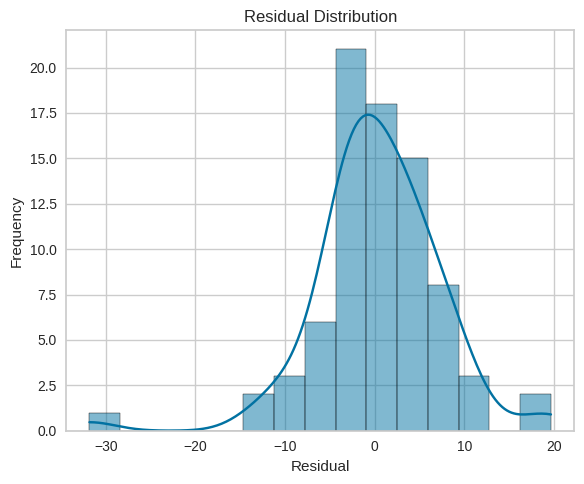

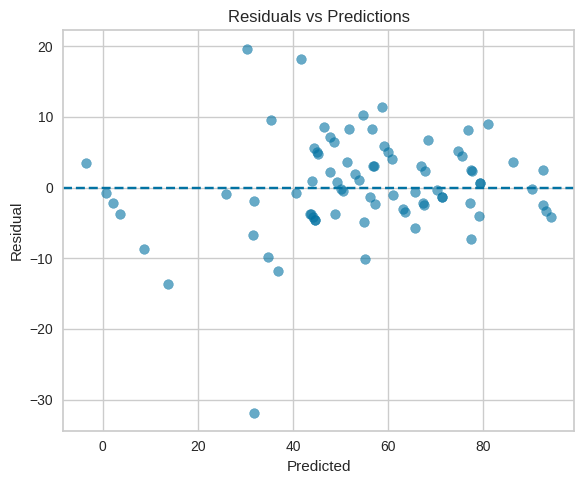


Model saved to: ../results/XGBoost_model.pkl

EVALUATION: ExtraTrees
MAE  : 5.4544
MSE  : 75.1181
RMSE : 8.6671
R2   : 0.8674
MAPE : 7137350295528937.0000


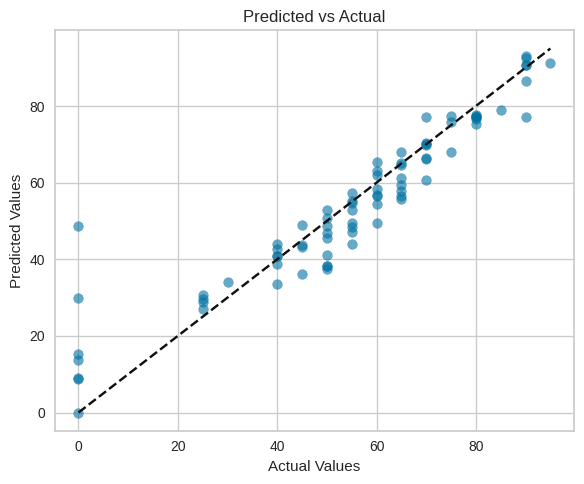

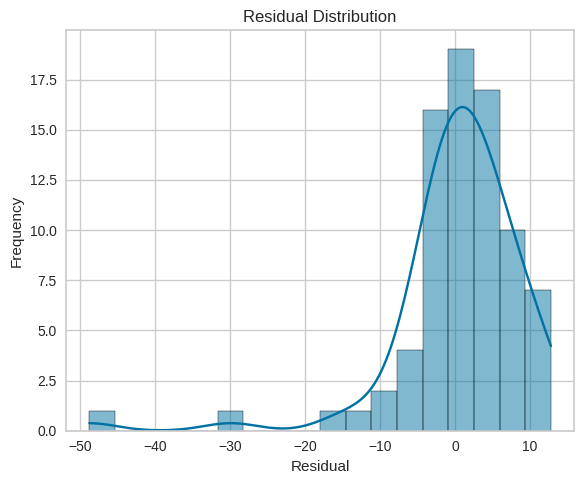

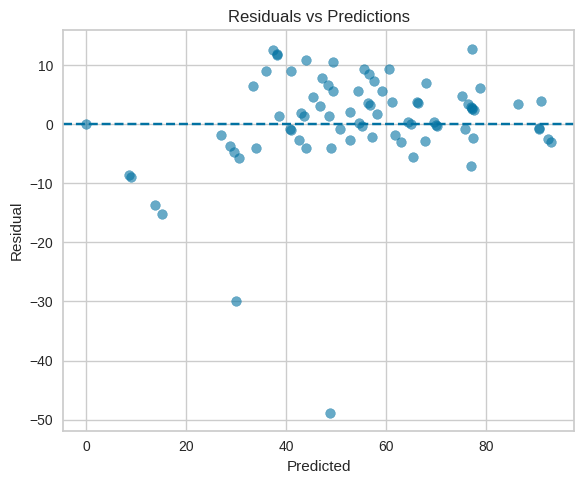


Model saved to: ../results/ExtraTrees_model.pkl

EVALUATION: GradientBoosting
MAE  : 4.8184
MSE  : 55.7331
RMSE : 7.4655
R2   : 0.9016
MAPE : 4416297610423684.0000


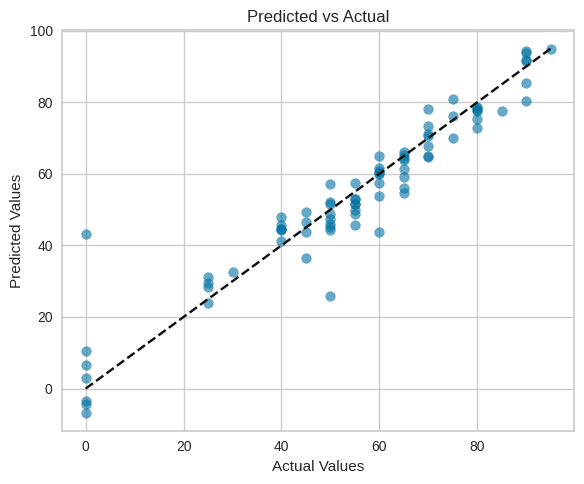

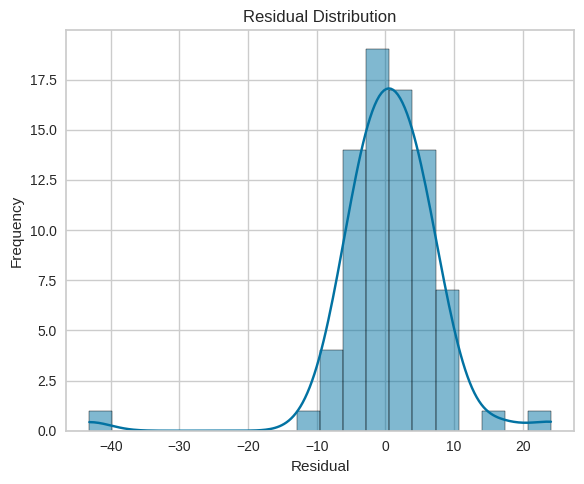

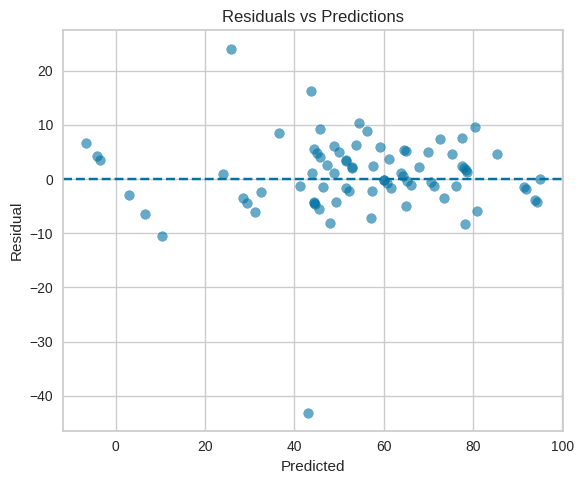


Model saved to: ../results/GradientBoosting_model.pkl


In [63]:
models_to_eval = {

    "RandomForest": models["RandomForest"],
    "CatBoost": models["CatBoost"],
    "XGBoost": models["XGBoost"],
    "ExtraTrees": models["ExtraTrees"],
    "GradientBoosting": models["GradientBoosting"]

}

for name, model in models_to_eval.items():

    evaluate_model(
        model=model,
        X_test=X_test,
        y_test=y_test,
        results_dir="../results/",
        name=name
    )



EVALUATION: ensemble_model
MAE  : 4.7518
MSE  : 51.3150
RMSE : 7.1634
R2   : 0.9094
MAPE : 4401783901724119.5000


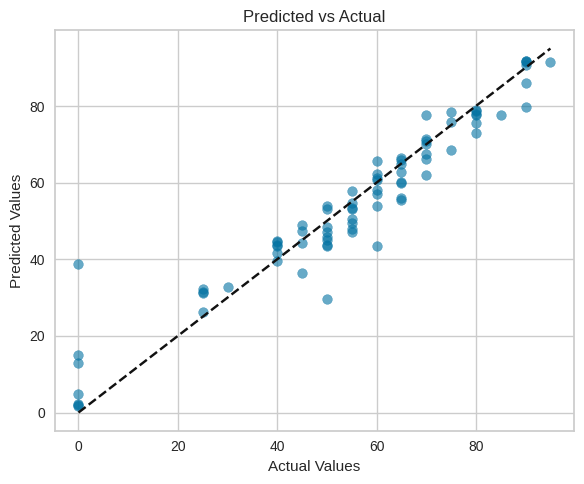

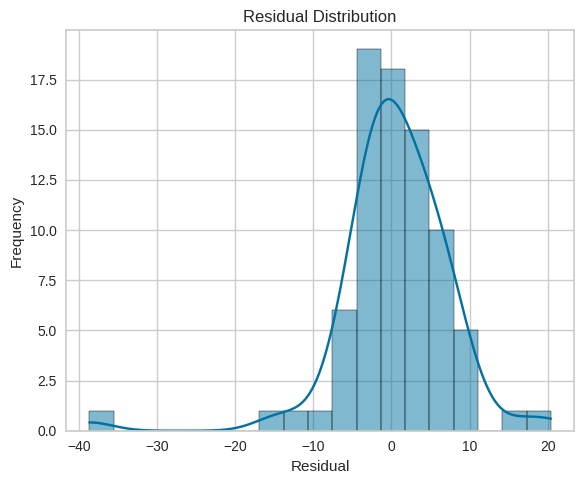

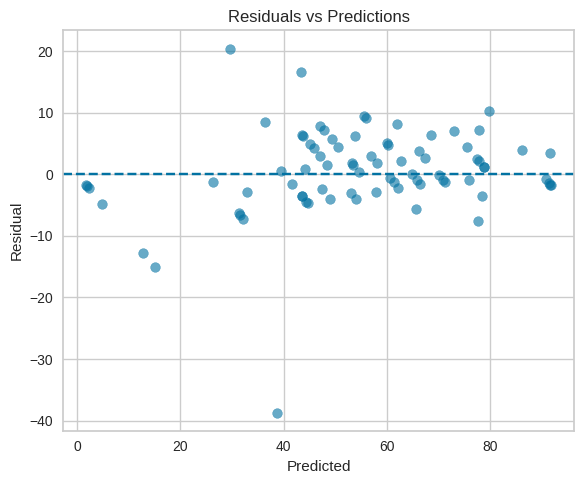


Model saved to: ../results/ensemble_model_model.pkl


In [64]:
evaluate_model(
    model=ensemble_model,
    X_test=X_test,
    y_test=y_test,
    results_dir="../results/",
    name="ensemble_model"
)